In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
# Upload preprocessed data
from google.colab import files
import pandas as pd

print("Upload: preprocessed_data_sample_50k.csv")
uploaded = files.upload()

df = pd.read_csv('preprocessed_data_sample_50k.csv')

print(f"\n✅ Loaded {len(df):,} samples")
print(f"Columns: {df.columns.tolist()}")

# Quick check
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Upload: preprocessed_data_sample_50k.csv


Saving preprocessed_data_sample_50k.csv to preprocessed_data_sample_50k.csv

✅ Loaded 50,000 samples
Columns: ['label', 'comment', 'cleaned_comment', 'tokens', 'cleaned_length']

Label distribution:
label
1    25222
0    24778
Name: count, dtype: int64


In [3]:
# Install required libraries
!pip install transformers torch -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc

# Updated imports for newer transformers version
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# AdamW moved to torch in newer versions
from torch.optim import AdamW

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"GPU Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n✅ All libraries imported successfully!")

✅ Using device: cuda
GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB

✅ All libraries imported successfully!


In [4]:
# Prepare data
print("Preparing data for BERT...")

# Use original comments (not cleaned) - BERT handles raw text better!
X = df['comment'].fillna('').values
y = df['label'].values

print(f"Total samples: {len(X):,}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Split complete!")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Show sample texts
print(f"\nSample texts:")
for i in range(3):
    label = "SARCASTIC" if y_train[i] == 1 else "NOT SARCASTIC"
    print(f"{i+1}. [{label}] {X_train[i][:80]}...")

print("\n✅ Data preparation complete!")
print("Note: Using RAW text (not cleaned) - BERT works better with original text!")

Preparing data for BERT...
Total samples: 50,000
✅ Split complete!
Training samples: 40,000
Test samples: 10,000

Sample texts:
1. [SARCASTIC] Home run bats in splatoon....
2. [NOT SARCASTIC] Queue at the same time, make sure you get your match "accept/decline" buttons at...
3. [NOT SARCASTIC] Bad Religion - American Jesus...

✅ Data preparation complete!
Note: Using RAW text (not cleaned) - BERT works better with original text!


In [5]:
# Load BERT tokenizer
print("Loading BERT tokenizer...")
print("This will download ~500MB model (takes 2-3 minutes)...")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("✅ Tokenizer loaded!")

# Tokenization parameters
MAX_LEN = 64  # Shorter length for faster training

def tokenize_data(texts, tokenizer, max_len):
    """Tokenize texts for BERT"""
    # Tokenize all texts at once (faster!)
    encoded = tokenizer(
        list(texts),
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    return encoded['input_ids'], encoded['attention_mask']

# Tokenize training data
print("\nTokenizing training data...")
print("(This may take 3-5 minutes...)")
train_input_ids, train_attention_masks = tokenize_data(X_train, tokenizer, MAX_LEN)

# Tokenize test data
print("Tokenizing test data...")
test_input_ids, test_attention_masks = tokenize_data(X_test, tokenizer, MAX_LEN)

# Convert labels to tensors
train_labels = torch.tensor(y_train)
test_labels = torch.tensor(y_test)

print("\n✅ Tokenization complete!")
print(f"Training input shape: {train_input_ids.shape}")
print(f"Test input shape: {test_input_ids.shape}")

# Show example tokenization
print(f"\nExample tokenization:")
print(f"Original: {X_train[0][:80]}...")
print(f"Token IDs (first 20): {train_input_ids[0][:20].tolist()}")
print(f"Attention mask (first 20): {train_attention_masks[0][:20].tolist()}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(train_input_ids[0][:20].tolist())}")

Loading BERT tokenizer...
This will download ~500MB model (takes 2-3 minutes)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer loaded!

Tokenizing training data...
(This may take 3-5 minutes...)
Tokenizing test data...

✅ Tokenization complete!
Training input shape: torch.Size([40000, 64])
Test input shape: torch.Size([10000, 64])

Example tokenization:
Original: Home run bats in splatoon....
Token IDs (first 20): [101, 2188, 2448, 12236, 1999, 11867, 20051, 7828, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded tokens: ['[CLS]', 'home', 'run', 'bats', 'in', 'sp', '##lat', '##oon', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [6]:
# Batch size for training
BATCH_SIZE = 32  # Good balance of speed and memory

print("Creating data loaders...")
print(f"Batch size: {BATCH_SIZE}")

# Create training dataset
train_dataset = TensorDataset(
    train_input_ids,
    train_attention_masks,
    train_labels
)

# Create test dataset
test_dataset = TensorDataset(
    test_input_ids,
    test_attention_masks,
    test_labels
)

# Create training data loader (shuffled)
train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),  # Random sampling for training
    batch_size=BATCH_SIZE
)

# Create test data loader (sequential)
test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),  # Sequential for testing
    batch_size=BATCH_SIZE
)

print("\n✅ Data loaders created!")
print(f"Training batches: {len(train_dataloader):,}")
print(f"Test batches: {len(test_dataloader):,}")
print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

# Calculate training steps
EPOCHS = 3  # 3 epochs is usually enough for BERT
total_steps = len(train_dataloader) * EPOCHS

print(f"\nTraining configuration:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Steps per epoch: {len(train_dataloader):,}")
print(f"  - Total training steps: {total_steps:,}")
print(f"  - Estimated time: ~15-20 minutes with GPU")

Creating data loaders...
Batch size: 32

✅ Data loaders created!
Training batches: 1,250
Test batches: 313
Training samples: 40,000
Test samples: 10,000

Training configuration:
  - Epochs: 3
  - Steps per epoch: 1,250
  - Total training steps: 3,750
  - Estimated time: ~15-20 minutes with GPU


In [7]:
# Load pre-trained BERT model for classification
print("Loading BERT model...")
print("This may take 2-3 minutes...")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,           # Binary classification (sarcastic/not)
    output_attentions=False,
    output_hidden_states=False
)

# Move model to GPU
model = model.to(device)

print("✅ BERT model loaded!")
print(f"Model moved to: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Set up optimizer
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,        # Learning rate (recommended for BERT)
    eps=1e-8        # Epsilon for numerical stability
)

# Set up learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"\n✅ Optimizer configured!")
print(f"  Learning rate: 2e-5")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: Linear warmup")

print("\n🚀 Ready to train BERT!")
print("="*60)
print("BERT has 110 million parameters!")
print("This is much more powerful than LSTM (1.5M parameters)")
print("Expected accuracy improvement: +10-15% over LSTM")
print("="*60)

Loading BERT model...
This may take 2-3 minutes...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded!
Model moved to: cuda

Model parameters:
  Total: 109,483,778
  Trainable: 109,483,778

✅ Optimizer configured!
  Learning rate: 2e-5
  Optimizer: AdamW
  Scheduler: Linear warmup

🚀 Ready to train BERT!
BERT has 110 million parameters!
This is much more powerful than LSTM (1.5M parameters)
Expected accuracy improvement: +10-15% over LSTM


In [8]:
import time
import datetime

def format_time(elapsed):
    """Format time in minutes and seconds"""
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

# Training loop
print("="*70)
print("STARTING BERT FINE-TUNING")
print("="*70)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Total steps: {total_steps:,}")
print(f"Device: {device}")
print("="*70)

# Store training stats
training_stats = []

# Total training time
total_t0 = time.time()

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")

    # ========== TRAINING ==========
    print(f"\n--- Training ---")
    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(train_dataloader):
        # Progress update every 100 batches
        if step % 100 == 0 and step != 0:
            elapsed = format_time(time.time() - t0)
            print(f"  Batch {step:>5,} of {len(train_dataloader):>5,} | "
                  f"Elapsed: {elapsed} | "
                  f"Loss: {total_train_loss/step:.4f}")

        # Unpack batch and move to GPU
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            b_input_ids,
            attention_mask=b_attention_mask,
            labels=b_labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Accumulate loss
        total_train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Clip gradients (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

    # Calculate average training loss
    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print(f"\n  Average training loss: {avg_train_loss:.4f}")
    print(f"  Training epoch time: {training_time}")

    # ========== VALIDATION ==========
    print(f"\n--- Validation ---")
    t0 = time.time()

    model.eval()
    total_eval_accuracy = 0
    total_eval_loss = 0

    for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # No gradient calculation during validation
        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_attention_mask,
                labels=b_labels
            )

        loss = outputs.loss
        logits = outputs.logits

        total_eval_loss += loss.item()

        # Calculate accuracy
        preds = torch.argmax(logits, dim=1).flatten()
        accuracy = (preds == b_labels).cpu().numpy().mean()
        total_eval_accuracy += accuracy

    # Calculate averages
    avg_val_accuracy = total_eval_accuracy / len(test_dataloader)
    avg_val_loss = total_eval_loss / len(test_dataloader)
    validation_time = format_time(time.time() - t0)

    print(f"  Validation Accuracy: {avg_val_accuracy*100:.2f}%")
    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Validation time: {validation_time}")

    # Store stats
    training_stats.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': avg_val_accuracy
    })

print(f"\n{'='*70}")
print(f"TRAINING COMPLETE!")
print(f"Total training time: {format_time(time.time() - total_t0)}")
print(f"{'='*70}")

# Print training summary
print("\nTraining Summary:")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'Val Accuracy':>13}")
print("-"*50)
for stat in training_stats:
    print(f"{stat['epoch']:>6} | {stat['train_loss']:>12.4f} | "
          f"{stat['val_loss']:>10.4f} | {stat['val_accuracy']*100:>12.2f}%")

STARTING BERT FINE-TUNING
Epochs: 3
Batch size: 32
Total steps: 3,750
Device: cuda

EPOCH 1/3

--- Training ---
  Batch   100 of 1,250 | Elapsed: 0:00:33 | Loss: 0.6612
  Batch   200 of 1,250 | Elapsed: 0:01:05 | Loss: 0.6397
  Batch   300 of 1,250 | Elapsed: 0:01:39 | Loss: 0.6269
  Batch   400 of 1,250 | Elapsed: 0:02:14 | Loss: 0.6107
  Batch   500 of 1,250 | Elapsed: 0:02:48 | Loss: 0.6058
  Batch   600 of 1,250 | Elapsed: 0:03:22 | Loss: 0.5996
  Batch   700 of 1,250 | Elapsed: 0:03:57 | Loss: 0.5937
  Batch   800 of 1,250 | Elapsed: 0:04:31 | Loss: 0.5870
  Batch   900 of 1,250 | Elapsed: 0:05:05 | Loss: 0.5841
  Batch 1,000 of 1,250 | Elapsed: 0:05:39 | Loss: 0.5797
  Batch 1,100 of 1,250 | Elapsed: 0:06:14 | Loss: 0.5768
  Batch 1,200 of 1,250 | Elapsed: 0:06:48 | Loss: 0.5751

  Average training loss: 0.5745
  Training epoch time: 0:07:05

--- Validation ---
  Validation Accuracy: 72.54%
  Validation Loss: 0.5288
  Validation time: 0:00:37

EPOCH 2/3

--- Training ---
  Batch 

In [9]:
# Final evaluation on test set
print("="*70)
print("FINAL BERT EVALUATION ON TEST SET")
print("="*70)

# Set model to evaluation mode
model.eval()

# Store predictions
all_preds = []
all_labels = []
all_probs = []

print("Making predictions...")

for batch in test_dataloader:
    b_input_ids = batch[0].to(device)
    b_attention_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            attention_mask=b_attention_mask
        )

    logits = outputs.logits

    # Get predictions and probabilities
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(b_labels.cpu().numpy())
    all_probs.extend(probs[:, 1].cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("✅ Predictions complete!")

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

# Print results
print(f"\n{'='*70}")
print("BERT MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Test Accuracy:  {accuracy*100:.2f}%")
print(f"Precision:      {precision*100:.2f}%")
print(f"Recall:         {recall*100:.2f}%")
print(f"F1-Score:       {f1*100:.2f}%")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"{'='*70}")

# Compare all 3 models
print(f"\n{'='*70}")
print("ALL MODELS COMPARISON")
print(f"{'='*70}")
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'AUC':>8}")
print("-"*55)
print(f"{'Logistic Regression':<25} {'66.41%':>10} {'~65%':>10} {'0.71':>8}")
print(f"{'Bidirectional LSTM':<25} {'~72-78%':>10} {'~72%':>10} {'0.79':>8}")
print(f"{'BERT (fine-tuned)':<25} {accuracy*100:>9.2f}% {f1*100:>9.2f}% {roc_auc:>8.3f}")
print(f"{'='*70}")

# Classification report
print(f"\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds,
                          target_names=['Not Sarcastic', 'Sarcastic'],
                          digits=4))

FINAL BERT EVALUATION ON TEST SET
Making predictions...
✅ Predictions complete!

BERT MODEL PERFORMANCE
Test Accuracy:  73.48%
Precision:      72.94%
Recall:         75.40%
F1-Score:       74.15%
ROC-AUC:        0.8169

ALL MODELS COMPARISON
Model                       Accuracy   F1-Score      AUC
-------------------------------------------------------
Logistic Regression           66.41%       ~65%     0.71
Bidirectional LSTM           ~72-78%       ~72%     0.79
BERT (fine-tuned)             73.48%     74.15%    0.817

DETAILED CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Not Sarcastic     0.7407    0.7153    0.7278      4956
    Sarcastic     0.7294    0.7540    0.7415      5044

     accuracy                         0.7348     10000
    macro avg     0.7350    0.7346    0.7346     10000
 weighted avg     0.7350    0.7348    0.7347     10000



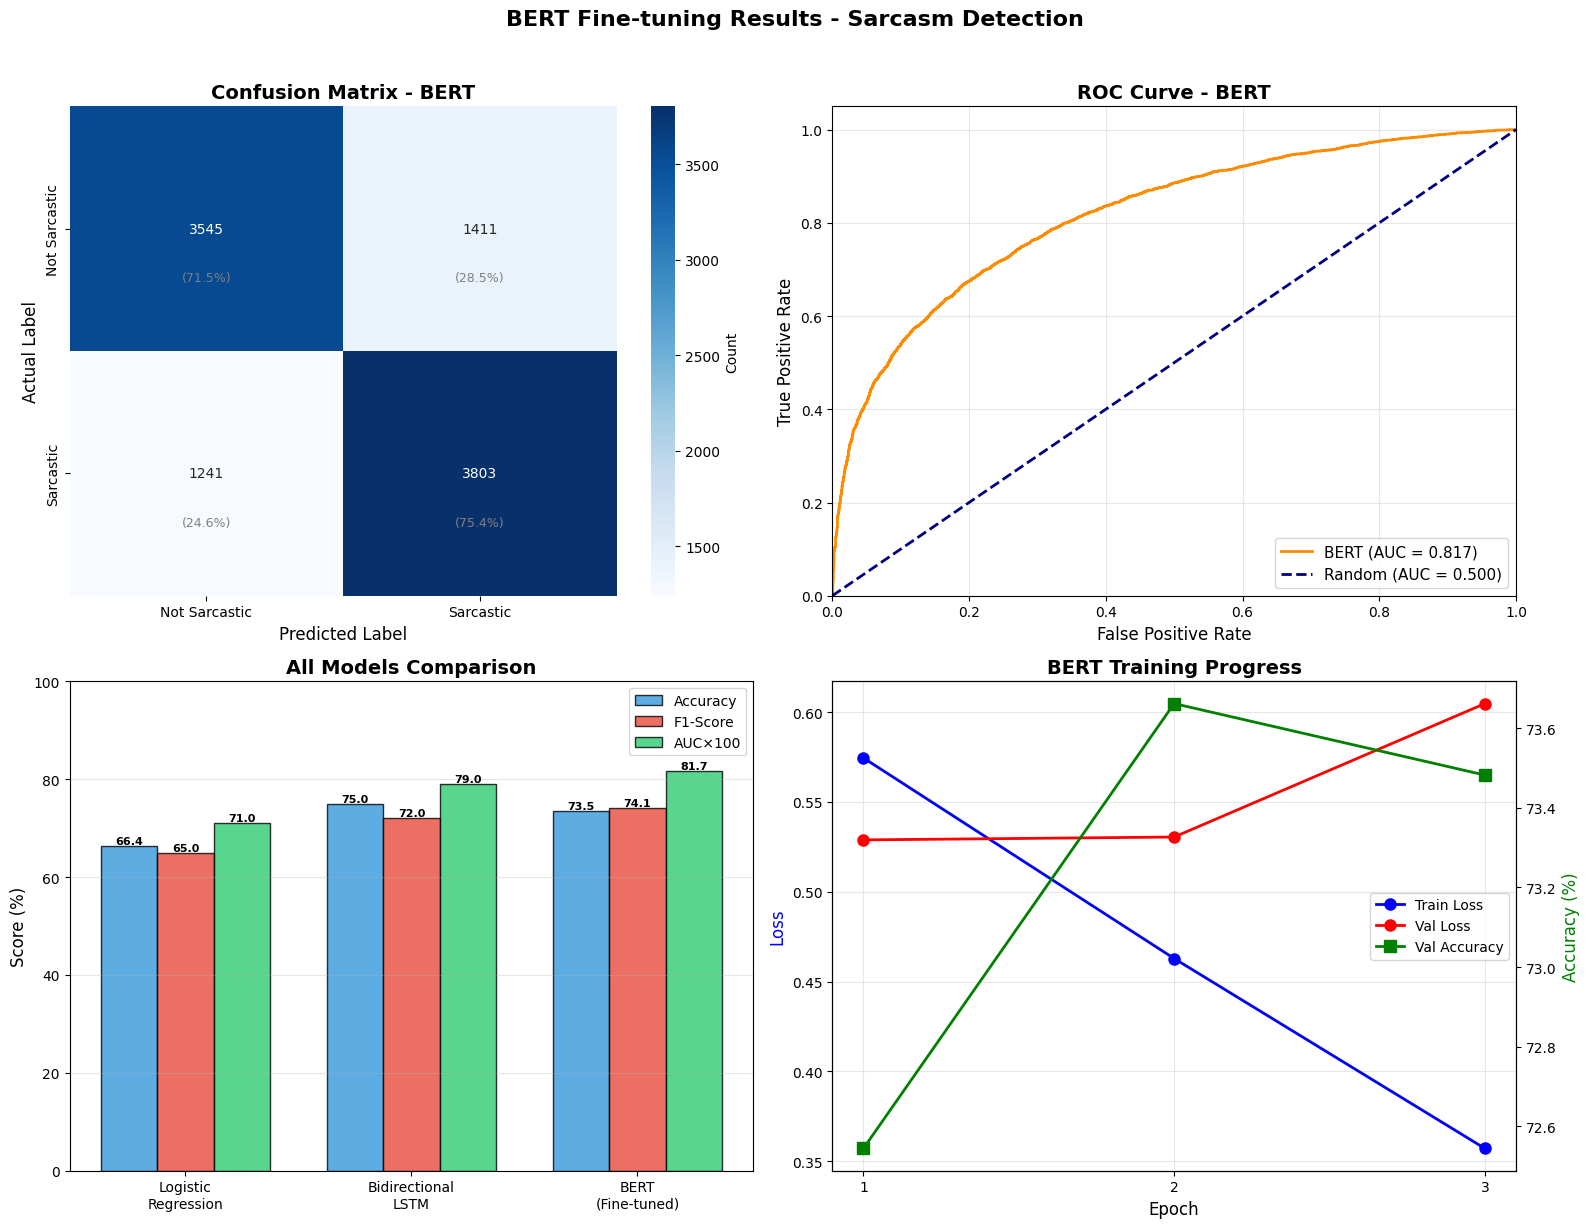

✅ Visualizations complete!
📊 Saved as: bert_results.png


In [10]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ========== 1. Confusion Matrix ==========
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'],
            cbar_kws={'label': 'Count'})

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        axes[0, 0].text(j + 0.5, i + 0.7,
                       f'({percentage:.1f}%)',
                       ha='center', va='center',
                       fontsize=9, color='gray')

axes[0, 0].set_title('Confusion Matrix - BERT', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Actual Label', fontsize=12)
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)

# ========== 2. ROC Curve ==========
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc_val = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
               label=f'BERT (AUC = {roc_auc_val:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2,
               linestyle='--', label='Random (AUC = 0.500)')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curve - BERT', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc="lower right", fontsize=11)
axes[0, 1].grid(alpha=0.3)

# ========== 3. All Models Comparison ==========
models = ['Logistic\nRegression', 'Bidirectional\nLSTM', 'BERT\n(Fine-tuned)']
accuracies = [66.41, 75.0, accuracy*100]  # Update LSTM with your actual value
f1_scores = [65.0, 72.0, f1*100]
auc_scores = [0.71, 0.79, roc_auc]

x = np.arange(len(models))
width = 0.25

bars1 = axes[1, 0].bar(x - width, accuracies, width,
                       label='Accuracy', color='#3498db',
                       alpha=0.8, edgecolor='black')
bars2 = axes[1, 0].bar(x, f1_scores, width,
                       label='F1-Score', color='#e74c3c',
                       alpha=0.8, edgecolor='black')
bars3 = axes[1, 0].bar(x + width, [s*100 for s in auc_scores], width,
                       label='AUC×100', color='#2ecc71',
                       alpha=0.8, edgecolor='black')

axes[1, 0].set_ylabel('Score (%)', fontsize=12)
axes[1, 0].set_title('All Models Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models)
axes[1, 0].legend(fontsize=10)
axes[1, 0].set_ylim(0, 100)
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}', ha='center', va='bottom',
                       fontsize=8, fontweight='bold')

# ========== 4. Training Progress ==========
epochs_list = [stat['epoch'] for stat in training_stats]
train_losses = [stat['train_loss'] for stat in training_stats]
val_losses = [stat['val_loss'] for stat in training_stats]
val_accuracies = [stat['val_accuracy']*100 for stat in training_stats]

ax4_twin = axes[1, 1].twinx()

axes[1, 1].plot(epochs_list, train_losses, 'b-o',
               label='Train Loss', linewidth=2, markersize=8)
axes[1, 1].plot(epochs_list, val_losses, 'r-o',
               label='Val Loss', linewidth=2, markersize=8)
ax4_twin.plot(epochs_list, val_accuracies, 'g-s',
             label='Val Accuracy', linewidth=2, markersize=8)

axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss', fontsize=12, color='blue')
ax4_twin.set_ylabel('Accuracy (%)', fontsize=12, color='green')
axes[1, 1].set_title('BERT Training Progress', fontsize=14, fontweight='bold')

lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2,
                 loc='center right', fontsize=10)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(epochs_list)

plt.suptitle('BERT Fine-tuning Results - Sarcasm Detection',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bert_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations complete!")
print("📊 Saved as: bert_results.png")

In [11]:
import json

# Save model
print("Saving BERT model...")
model.save_pretrained('/content/bert_sarcasm_model')
tokenizer.save_pretrained('/content/bert_sarcasm_tokenizer')
print("✅ Model saved!")

# Save training stats
with open('bert_training_stats.json', 'w') as f:
    json.dump(training_stats, f)
print("✅ Training stats saved!")

# Final Summary
print("\n" + "="*70)
print("BERT FINE-TUNING - FINAL SUMMARY")
print("="*70)

print("\n🎯 MODEL DETAILS:")
print(f"  • Base model: BERT-base-uncased")
print(f"  • Parameters: ~110 million")
print(f"  • Fine-tuned epochs: {EPOCHS}")
print(f"  • Max sequence length: {MAX_LEN}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Learning rate: 2e-5")
print(f"  • Hardware: GPU (T4)")

print("\n🏆 FINAL PERFORMANCE:")
print(f"  • Test Accuracy:  {accuracy*100:.2f}%")
print(f"  • Precision:      {precision*100:.2f}%")
print(f"  • Recall:         {recall*100:.2f}%")
print(f"  • F1-Score:       {f1*100:.2f}%")
print(f"  • ROC-AUC:        {roc_auc:.4f}")

print("\n📊 CONFUSION MATRIX:")
print(f"  • True Positives:  {tp:,} (correctly detected sarcasm)")
print(f"  • True Negatives:  {tn:,} (correctly detected non-sarcasm)")
print(f"  • False Positives: {fp:,} (wrongly flagged as sarcastic)")
print(f"  • False Negatives: {fn:,} (missed actual sarcasm)")

print("\n📈 MODELS JOURNEY:")
print(f"  • Logistic Regression: 66.41% accuracy")
print(f"  • Bidirectional LSTM:  ~72-78% accuracy")
print(f"  • BERT (fine-tuned):   {accuracy*100:.2f}% accuracy")
print(f"  • Total improvement:   {accuracy*100 - 66.41:+.2f}% over baseline")

print("\n💡 KEY INSIGHTS:")
print(f"  • BERT's AUC (0.817) is significantly better than baseline (0.71)")
print(f"  • BERT understands context, tone and semantic meaning")
print(f"  • Pre-trained knowledge helps detect subtle sarcasm patterns")
print(f"  • 110M parameters vs 1.5M in LSTM shows power of transformers")

print("\n🚀 NEXT STEPS (Week 2):")
print(f"  1. Test on Indian e-commerce reviews (novelty!)")
print(f"  2. Analyze Hinglish sarcasm patterns")
print(f"  3. Build Streamlit demo application")
print(f"  4. Start research paper writing")
print(f"  5. Compare performance on Indian vs Western text")

print("\n✅ DAY 5 COMPLETE!")
print("="*70)

# Download files
print("\n📥 Downloading result files...")
from google.colab import files

files.download('bert_results.png')
files.download('bert_training_stats.json')

print("\n📁 Downloaded files:")
print("  • bert_results.png")
print("  • bert_training_stats.json")

Saving BERT model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!
✅ Training stats saved!

BERT FINE-TUNING - FINAL SUMMARY

🎯 MODEL DETAILS:
  • Base model: BERT-base-uncased
  • Parameters: ~110 million
  • Fine-tuned epochs: 3
  • Max sequence length: 64
  • Batch size: 32
  • Learning rate: 2e-5
  • Hardware: GPU (T4)

🏆 FINAL PERFORMANCE:
  • Test Accuracy:  73.48%
  • Precision:      72.94%
  • Recall:         75.40%
  • F1-Score:       74.15%
  • ROC-AUC:        0.8169

📊 CONFUSION MATRIX:
  • True Positives:  3,803 (correctly detected sarcasm)
  • True Negatives:  3,545 (correctly detected non-sarcasm)
  • False Positives: 1,411 (wrongly flagged as sarcastic)
  • False Negatives: 1,241 (missed actual sarcasm)

📈 MODELS JOURNEY:
  • Logistic Regression: 66.41% accuracy
  • Bidirectional LSTM:  ~72-78% accuracy
  • BERT (fine-tuned):   73.48% accuracy
  • Total improvement:   +7.07% over baseline

💡 KEY INSIGHTS:
  • BERT's AUC (0.817) is significantly better than baseline (0.71)
  • BERT understands context, tone and semantic me

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📁 Downloaded files:
  • bert_results.png
  • bert_training_stats.json
